# **Implementación del caso de 5 Qubits**

In [12]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q

from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
seed = 99

In [14]:
N5 = 48567227

In [15]:
fiveQubit = sl.schnorrCVP(N5, 3, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 50


## **1. Algoritmo de Schnorr**

In [16]:
cvpinstance = fiveQubit.generate_cvp(10)

B = 
[ 2 0 0 0 0  693 ]
[ 0 3 0 0 0 1099 ]
[ 0 0 1 0 0 1609 ]
[ 0 0 0 1 0 1946 ]
[ 0 0 0 0 2 2398 ]
t = 
(0, 0, 0, 0, 0, 17698)


In [17]:
cvpResult = fiveQubit.babai_algorithm(cvpinstance, delta = 0.75)
print(f'D5 = \n{cvpResult.D}\n')
print(f'b_op5 = \n{cvpResult.b_op}\n')
print(f'res_vector5 = \n{cvpResult.res_vector}\n')
print(f'step_sign5 = \n{cvpResult.step_sign}\n')
print(f'weights5 = \n{cvpResult.weight}\n')

D5 = 
[ -4  0  3 -3 2  1 ]
[  4  6 -4 -1 4 -2 ]
[  0 -3 -5  1 6 -4 ]
[ -6  3 -6  3 4  0 ]
[  4  0  1 -4 4  7 ]

b_op5 = 
[   -2     3     2     6     2 17698]

res_vector5 = 
[ 2 -3 -2 -6 -2  0]

step_sign5 = 
[ 1 -1  1 -1  1]

weights5 = 
(-1145, -1100, -946, 1255, 1837)



## **2. Algoritmo QAOA**

In [18]:
qubo5 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, fiveQubit.n)
print(qubo5.prettyprint())

Hc5, offset5 = q.define_hamiltonian(qubo5)
print(f'Offset = {offset5}')
print(f'Hamiltonian = \n{Hc5}')

Problem name: quboProblem

Minimize
  39*z_0^2 + 38*z_0*z_1 - 20*z_0*z_2 - 10*z_0*z_3 + 28*z_0*z_4 + 89*z_1^2
  - 66*z_1*z_2 + 62*z_1*z_3 - 36*z_1*z_4 + 87*z_2^2 - 96*z_2*z_3 - 26*z_2*z_4
  + 106*z_3^2 + 52*z_3*z_4 + 98*z_4^2 - 8*z_1 - 2*z_2 - 70*z_3 - 44*z_4 + 57

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4

Offset = 186.0
Hamiltonian = 
SparsePauliOp(['IIIZI', 'IZIII', 'ZIIII', 'IIZII', 'IIIIZ', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-40. +0.j, -20. +0.j, -31.5+0.j,   9.5+0.j, -28.5+0.j,   9.5+0.j,
  -5. +0.j,  -2.5+0.j,   7. +0.j, -16.5+0.j,  15.5+0.j,  -9. +0.j,
 -24. +0.j,  -6.5+0.j,  13. +0.j])


In [19]:
formatted_h = " + ".join([f"{c.real:.3f}{s}" for s, c in Hc5.label_iter()])
print(formatted_h)

-40.000IIIZI + -20.000IZIII + -31.500ZIIII + 9.500IIZII + -28.500IIIIZ + 9.500IIIZZ + -5.000IIZIZ + -2.500IZIIZ + 7.000ZIIIZ + -16.500IIZZI + 15.500IZIZI + -9.000ZIIZI + -24.000IZZII + -6.500ZIZII + 13.000ZZIII


In [20]:
circuit5 = q.construct_circuit(Hc5, reps= 1)
print(circuit5)

     ┌───┐┌────────────────┐                                               »
q_0: ┤ H ├┤ Rz((-57)*γ[0]) ├─■─────────────■────────────────■──────────────»
     ├───┤├────────────────┤ │ZZ(19*γ[0])  │                │              »
q_1: ┤ H ├┤ Rz((-80)*γ[0]) ├─■─────────────┼────────────────┼──────────────»
     ├───┤└┬─────────────┬─┘               │ZZ((-10)*γ[0])  │              »
q_2: ┤ H ├─┤ Rz(19*γ[0]) ├─────────────────■────────────────┼──────────────»
     ├───┤┌┴─────────────┴─┐                                │ZZ((-5)*γ[0]) »
q_3: ┤ H ├┤ Rz((-40)*γ[0]) ├────────────────────────────────■──────────────»
     ├───┤├────────────────┤                                               »
q_4: ┤ H ├┤ Rz((-63)*γ[0]) ├───────────────────────────────────────────────»
     └───┘└────────────────┘                                               »
«                                    ┌────────────┐                 »
«q_0: ──────────────────■────────────┤ Rx(2*β[0]) ├─────────────────»
«            

In [21]:
x0 = np.asarray([0.0]*circuit5.num_parameters)
#x0 = np.random.uniform(0, 2*np.pi, circuit5.num_parameters)
monitor, optParameters10 = q.qaoa_algorithm(circuit5, Hc5, x0)

In [22]:
print(f'Iteraciones = {monitor.iterations}')
print(f'Evolucion: ')
for angles, value in zip(monitor.parameters, monitor.evaluation):
    print(f'{angles}: {value}')

Iteraciones = 55
Evolucion: 
[-0.0005    0.000375]: -0.005246363453489293
[-0.00075    0.0009375]: -0.01964321304323663
[-0.001875    0.00146875]: -0.07672543356695828
[-0.0029375   0.00285937]: -0.23104231256742028
[-0.00571875  0.00461719]: -0.7061455592509789
[-0.00923438  0.00827734]: -1.847068374927115
[-0.01655469  0.01362305]: -4.211194948703215
[-0.02007031  0.0172832 ]: -5.010723474959679
[-0.02739063  0.02262891]: -5.364818561736015
[-0.02739063  0.02262891]: -5.364818561736015
[-0.0237124   0.02007947]: -5.378685671747054
[-0.02378467  0.01958582]: -5.512432857410635
[-0.02378467  0.01958582]: -5.512432857410635
[-0.02660657  0.02106595]: -5.736802710820306
[-0.02444769  0.0185161 ]: -5.89240086214534
[-0.02901205  0.02020144]: -6.527671854642048
[-0.02697649  0.01594441]: -6.854531523057109
[-0.03508743  0.01718657]: -8.714651137034016
[-0.03508743  0.01718657]: -8.714651137034016
[-0.04825595  0.01328536]: -12.039694847629526
[-0.05891135  0.01984882]: -13.260972749262853


In [23]:
for param in optParameters10.items():
    print(f'{param[0]} = {param[1]}')

β[0] = -0.49347615406731615
γ[0] = 0.014555044955926336


In [24]:
results5= q.sample_from_parameters(circuit5, list(optParameters10.values()), shots = 10_000)
print(len(results5))
for bitstring, count in results5.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

31
Bistring: 00000 -> Counts: 2179
Bistring: 01100 -> Counts: 1563
Bistring: 01101 -> Counts: 826
Bistring: 00100 -> Counts: 793
Bistring: 00110 -> Counts: 671
Bistring: 10110 -> Counts: 658
Bistring: 00001 -> Counts: 548
Bistring: 10000 -> Counts: 472
Bistring: 10100 -> Counts: 413
Bistring: 01000 -> Counts: 283
Bistring: 00101 -> Counts: 278
Bistring: 01010 -> Counts: 159
Bistring: 11100 -> Counts: 153
Bistring: 10010 -> Counts: 145
Bistring: 01110 -> Counts: 139
Bistring: 01001 -> Counts: 126
Bistring: 00010 -> Counts: 118
Bistring: 00111 -> Counts: 104
Bistring: 10101 -> Counts: 92
Bistring: 11010 -> Counts: 60
Bistring: 01011 -> Counts: 60
Bistring: 11000 -> Counts: 43
Bistring: 11110 -> Counts: 29
Bistring: 10111 -> Counts: 20
Bistring: 11001 -> Counts: 16
Bistring: 11101 -> Counts: 14
Bistring: 10001 -> Counts: 13
Bistring: 00011 -> Counts: 10
Bistring: 11111 -> Counts: 8
Bistring: 11011 -> Counts: 5
Bistring: 10011 -> Counts: 2


## **3. Obtención de SR-Pairs**

In [25]:
nD5 = sl.integer_to_matrix(cvpResult.D)
vnew5 = sl.bitstring2latticeVectors(nD5, results5.keys(), cvpResult.step_sign, cvpResult.b_op)

In [26]:
distances5 = utils.get_distances(vnew5, cvpinstance.t)

In [27]:
nB5 = sl.integer_to_matrix(cvpinstance.B)
uv_pairs5 = sl.vectors2uv_pairs(nB5, vnew5, fiveQubit.n)
for pair5 in uv_pairs5:
    print(pair5)

[97060425 2]
[145260500 3]
[145578125 3]
[12057493063 250]
[3487704605 72]
[878826025 18]
[389090625 8]
[48914250 1]
[1215290846 25]
[535937500 11]
[386683451 8]
[586181640625 11979]
[146410000 3]
[294765625 6]
[1313046875 27]
[48828125 1]
[12867859375 264]
[13981323125 288]
[97435855 2]
[4882812500 99]
[213623046875 4356]
[343750000 7]
[1323437500 27]
[3522990625 72]
[118164062500 2401]
[50328437500 1029]
[686296875 14]
[4689453125 96]
[64990234375 1323]
[152587890625 3087]
[1181640625 24]


In [28]:
sr_pairs5 = sl.uv_pairs2sr_pairs(uv_pairs5, fiveQubit)
print(sr_pairs5)

[((145578125, 3), -123556), ((48914250, 1), 347023), ((48828125, 1), 260898), ((97435855, 2), 301401)]


In [29]:
probs5 = utils.get_probs(results5.values(), shots = 10_000)

In [30]:
utils.prettyprint(vnew5, distances5, probs5, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [   -2     3     2     6     2 17698]

El vector residual 
t - b_op = [ 2 -3 -2 -6 -2  0]

La distancia |t - b_op| = 7.550

0: Prob = 0.21790
	vnew = [   -2     3     2     6     2 17698] con distancia: 7.550
1: Prob = 0.15630
	vnew = [    4    -3     3     4     4 17694] con distancia: 9.055
2: Prob = 0.08260
	vnew = [    0    -3     6     1     6 17695] con distancia: 9.539
3: Prob = 0.07930
	vnew = [   -2     0    -3     7     8 17694] con distancia: 11.916
4: Prob = 0.06710
	vnew = [   -6    -6     1     8     4 17696] con distancia: 12.530
5: Prob = 0.06580
	vnew = [   -2    -6     2     4     8 17703] con distancia: 12.207
6: Prob = 0.05480
	vnew = [   -6     3     5     3     4 17699] con distancia: 9.798
7: Prob = 0.04720
	vnew = [    2     3     3     2     6 17705] con distancia: 10.536
8: Prob = 0.04130
	vnew = [    2     0    -2     3    12 17701] con distancia: 13.038
9: Prob = 0.02830
	vnew = [    4     0     8     3    -2 

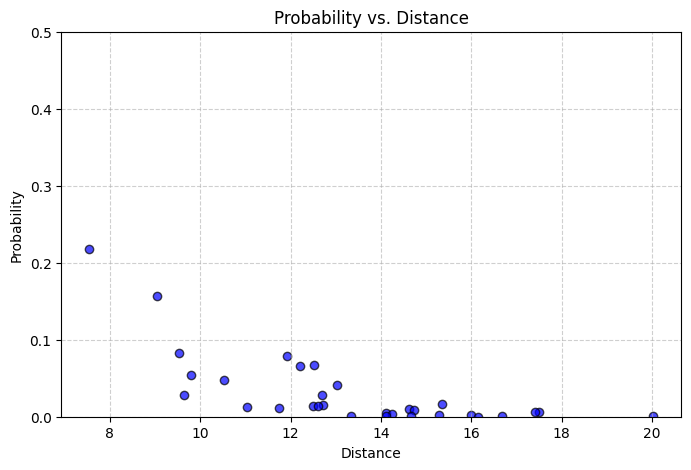

In [31]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances5, probs5, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.5) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/5QubitCase_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()

## **4. Landscape del QAOA**

In [32]:
grid = 300

betha_grid = np.linspace(0, np.pi, grid)
gamma_grid = np.linspace(0, 2*np.pi, grid)

B, G = np.meshgrid(betha_grid, gamma_grid)

param_vals = np.column_stack([B.ravel(), G.ravel()])

In [33]:
evals = q.evaluate_params(circuit5, Hc5, param_vals)

Z = evals.reshape(grid, grid)

In [34]:
#Normalizar entre [-1, 1]
zmin, zmax = Z.min(), Z.max()
z_norm = 2*(Z - zmin)/(zmax - zmin) - 1

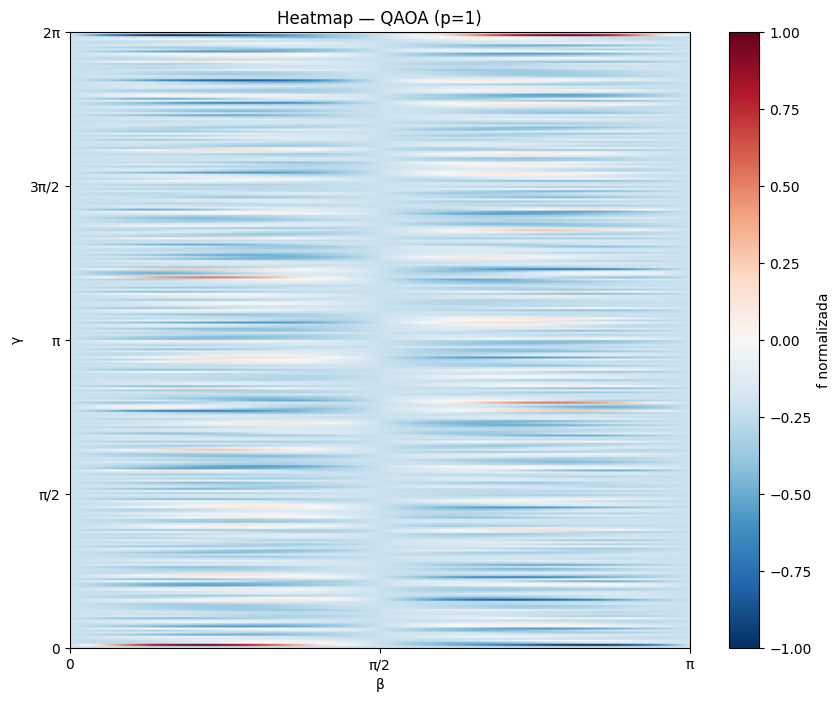

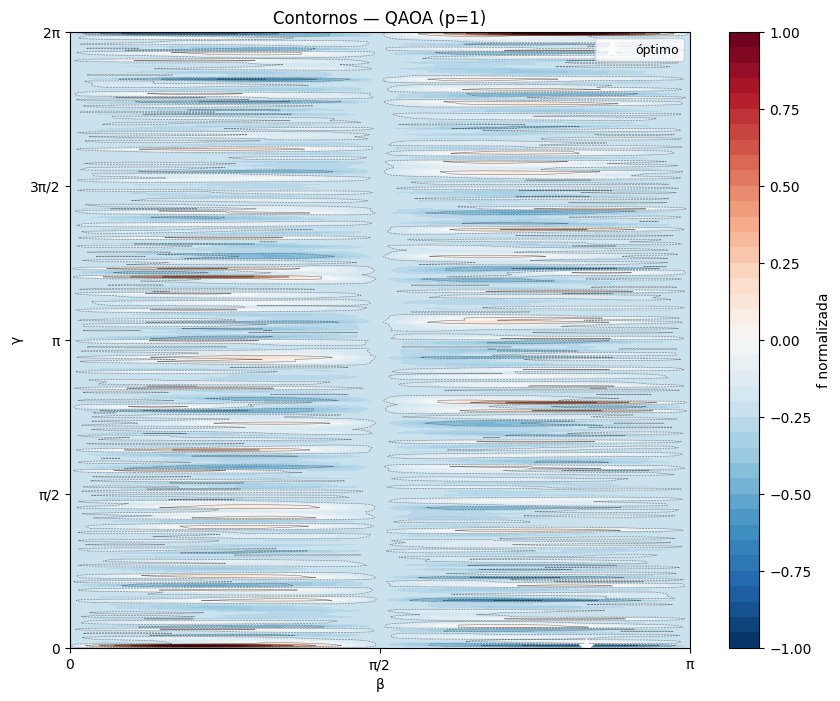

In [35]:
ticks_b = [0, np.pi/2, np.pi]
ticks_g = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

lbls_b = ["0", "π/2", "π"]
lbls_g = ["0", "π/2", "π", "3π/2", "2π"]

def _format_ax(ax):
    ax.set_xticks(ticks_b); ax.set_xticklabels(lbls_b)
    ax.set_yticks(ticks_g); ax.set_yticklabels(lbls_g)
    ax.set_xlabel("β"); ax.set_ylabel("γ")

# — Figura 1: heatmap ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 8))
im = ax1.imshow(
    z_norm, origin="lower", aspect="auto",
    extent=[0, np.pi, 0, 2*np.pi],
    cmap="RdBu_r", vmin=-1, vmax=1
)
fig1.colorbar(im, ax=ax1, label="f normalizada")
_format_ax(ax1)
ax1.set_title(f"Heatmap — QAOA (p={1})")
#fig1.tight_layout()
fig1.savefig("figures/5QubitCase_heatmap.png", dpi=150)

# — Figura 2: contornos ─────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 8))
cf = ax2.contourf(B, G, z_norm, levels=40, cmap="RdBu_r", vmin=-1, vmax=1)
ax2.contour(B, G, z_norm, levels=10, colors="k", linewidths=0.4, alpha=0.5)

idx = np.unravel_index(z_norm.argmin(), z_norm.shape)
ax2.plot(B[idx], G[idx], "w*", ms=11, label="óptimo")
ax2.legend(fontsize=9)

fig2.colorbar(cf, ax=ax2, label="f normalizada")
_format_ax(ax2)
ax2.set_title(f"Contornos — QAOA (p={1})")
#fig2.tight_layout()
fig2.savefig("figures/5QubitCase_contornos.png", dpi=180)

plt.show()